# Image Quality Assessment (IQA) - CNN Model
## Klasifikasi Kualitas Gambar untuk Autonomous Mobile Robot (AMR) Camera

Notebook ini membangun model **CNN dari scratch** untuk mengklasifikasikan kualitas gambar ke dalam 3 kategori:
- **Normal** - Gambar dengan kualitas baik (pencahayaan cukup, fokus tajam)
- **Blur** - Gambar yang blur/tidak fokus
- **Lowlight** - Gambar dengan pencahayaan rendah

**Arsitektur:** CNN 4-block (32→64→128→256 filter) + Dense head  
**Dataset:** LOL (Low-Light) + Blur Dataset Scaled  
**Framework:** TensorFlow/Keras  
**Export:** `model/` + TFLite

## 1. Setup & Import Libraries

In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Memory growth enabled for {len(gpus)} GPU(s)")

# Mixed precision — aktifkan Tensor Core di T4/V100/A100
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f"Compute dtype: {tf.keras.mixed_precision.global_policy().compute_dtype}")

I0000 00:00:1782028857.683864    4240 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled for 1 GPU(s)
Compute dtype: float16


## 2. Data Preparation

In [2]:
BASE_DIR = 'data'
os.makedirs('model', exist_ok=True)
IMG_SIZE    = (320, 320)   # ↑ dari 160 → lebih detail untuk blur/texture detection
BATCH_SIZE  = 32
CLASS_NAMES = ['Blur', 'Lowlight', 'Normal']

def get_file_paths_and_labels(split='train'):
    """Load dari data/<Class>/<split>/ langsung — tanpa subfolder."""
    paths, labels = [], []
    for label_idx, class_name in enumerate(CLASS_NAMES):
        folder = os.path.join(BASE_DIR, class_name, split)
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(folder, fname))
                labels.append(label_idx)
    return paths, labels

train_paths, train_labels = get_file_paths_and_labels('train')
val_paths,   val_labels   = get_file_paths_and_labels('valid')
test_paths,  test_labels  = get_file_paths_and_labels('test')

print(f"Train : {len(train_paths)}")
print(f"Valid : {len(val_paths)}")
print(f"Test  : {len(test_paths)}")
print(f"IMG_SIZE: {IMG_SIZE}  |  BATCH_SIZE: {BATCH_SIZE}")

from collections import Counter
print("\nDistribusi train:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {Counter(train_labels)[i]}")

Train : 1640
Valid : 205
Test  : 205
IMG_SIZE: (320, 320)  |  BATCH_SIZE: 32

Distribusi train:
  Blur: 560
  Lowlight: 400
  Normal: 680


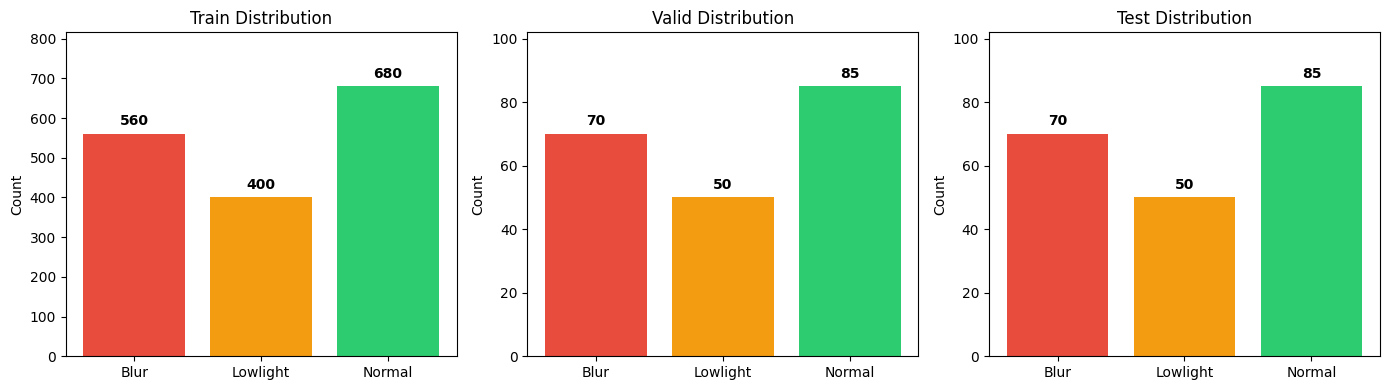

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for idx, (split_name, labels) in enumerate([('Train', train_labels), ('Valid', val_labels), ('Test', test_labels)]):
    unique, counts = np.unique(labels, return_counts=True)
    bars = axes[idx].bar([CLASS_NAMES[i] for i in unique], counts,
                         color=['#e74c3c', '#f39c12', '#2ecc71'])
    axes[idx].set_title(f'{split_name} Distribution')
    axes[idx].set_ylabel('Count')
    axes[idx].set_ylim(0, max(counts) * 1.2)
    for bar, c in zip(bars, counts):
        axes[idx].annotate(
            str(c),
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center', va='bottom', fontweight='bold'
        )
plt.tight_layout()
plt.show()

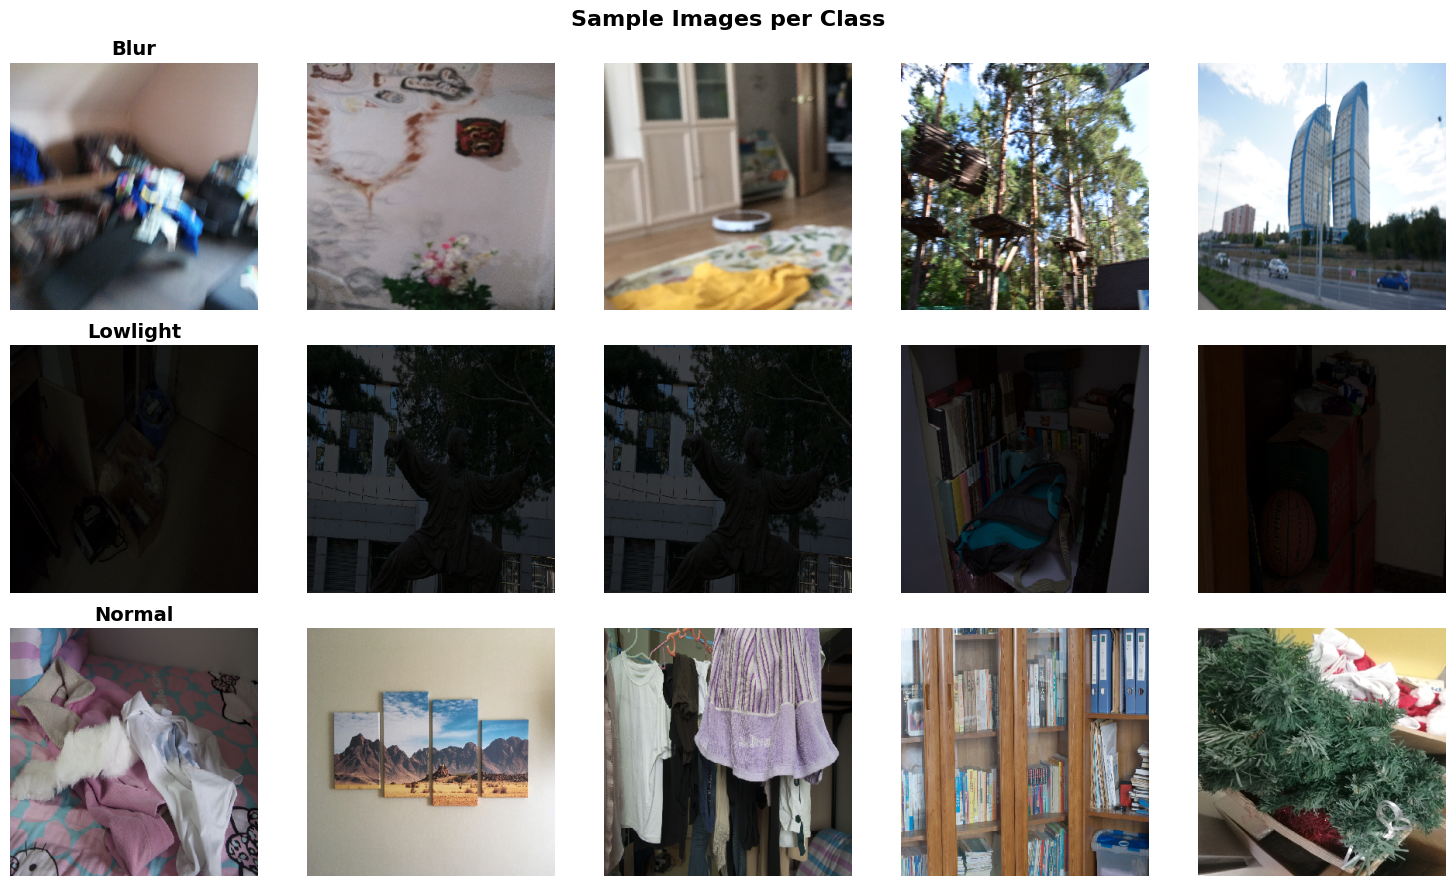

In [4]:
# Sample images per kelas
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for row, class_name in enumerate(CLASS_NAMES):
    class_indices = [i for i, l in enumerate(train_labels) if l == row]
    samples = np.random.choice(class_indices, 5, replace=False)
    for col, idx in enumerate(samples):
        img = tf.keras.utils.load_img(train_paths[idx], target_size=IMG_SIZE)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(class_name, fontsize=14, fontweight='bold')
plt.suptitle('Sample Images per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data Pipeline (tf.data)

In [5]:
def parse_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])          # wajib untuk graph mode
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def apply_blur(img):
    """Simulasi blur via downscale-upscale — domain-critical untuk kelas Blur."""
    bf = tf.random.uniform((), 0.25, 0.65)
    sz = tf.cast(tf.cast(IMG_SIZE[0], tf.float32) * bf, tf.int32)
    sz = tf.maximum(sz, 32)
    return tf.image.resize(tf.image.resize(img, [sz, sz]), IMG_SIZE)

def augment_image(img, label):
    """Augmentasi kuat & domain-specific untuk IQA (blur + lowlight simulation)."""
    # Geometric
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)

    # Photometric — simulasi variasi pencahayaan kamera AMR
    img = tf.image.random_brightness(img, max_delta=0.3)
    img = tf.image.random_contrast(img, lower=0.6, upper=1.4)
    img = tf.image.random_saturation(img, lower=0.6, upper=1.4)
    img = tf.image.random_hue(img, max_delta=0.08)

    # Simulasi blur (25% chance) — domain-critical untuk kelas Blur
    img = tf.cond(
        tf.random.uniform(()) < 0.25,
        lambda: apply_blur(img),
        lambda: img
    )

    # Gaussian noise (20% chance) — simulasi sensor noise kamera
    img = tf.cond(
        tf.random.uniform(()) < 0.2,
        lambda: img + tf.random.normal(tf.shape(img), mean=0.0, stddev=0.03),
        lambda: img
    )

    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def create_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()     # cache decoded images — hemat disk I/O tiap epoch
    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds   = create_dataset(val_paths,   val_labels,   training=False)
test_ds  = create_dataset(test_paths,  test_labels,  training=False)

for images, labels_batch in train_ds.take(1):
    print(f"Batch shape : {images.shape}")
    print(f"Labels shape: {labels_batch.shape}")
    print(f"Pixel range : [{images.numpy().min():.3f}, {images.numpy().max():.3f}]")

I0000 00:00:1782028863.905415    4240 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782028876.097490    4303 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 976 of 1640
I0000 00:00:1782028882.487685    4303 shuffle_dataset_op.cc:483] Shuffle buffer filled.


Batch shape : (32, 320, 320, 3)
Labels shape: (32,)
Pixel range : [0.000, 1.000]


## 4. CNN Model Architecture

In [6]:
from tensorflow.keras.regularizers import l2

def se_block(x, ratio=8):
    """Squeeze-and-Excitation — channel attention untuk highlight fitur IQA penting."""
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // ratio, activation='relu',
                      kernel_regularizer=l2(1e-4))(se)
    se = layers.Dense(channels, activation='sigmoid',
                      kernel_regularizer=l2(1e-4))(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])

def conv_block(x, filters, dropout_rate, use_se=True, pool=True):
    """Residual block: 2x Conv + BN + residual skip + optional SE + optional MaxPool."""
    shortcut = x
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False,
                                 kernel_regularizer=l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Conv2D(filters, 3, padding='same', use_bias=False,
                      kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False,
                      kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    if use_se:
        x = se_block(x)

    if pool:
        x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

def build_model(input_shape=(*IMG_SIZE, 3), num_classes=3):
    inputs = keras.Input(shape=input_shape)

    # Spatial augmentation (aktif hanya saat training=True)
    x = layers.RandomRotation(0.08)(inputs)
    x = layers.RandomZoom(0.1)(x)

    # Stem: ekstraksi fitur awal 320x320
    x = layers.Conv2D(32, 3, padding='same', use_bias=False,
                      kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Block 1: 320→160, 64  filters (low-level edges, no SE)
    x = conv_block(x, 64,  dropout_rate=0.2,  use_se=False)
    # Block 2: 160→80,  128 filters + SE
    x = conv_block(x, 128, dropout_rate=0.25, use_se=True)
    # Block 3: 80→40,   256 filters + SE
    x = conv_block(x, 256, dropout_rate=0.3,  use_se=True)
    # Block 4: 40→20,   512 filters + SE
    x = conv_block(x, 512, dropout_rate=0.35, use_se=True)
    # Block 5: 20→10,   512 filters + SE (deep abstract representation)
    x = conv_block(x, 512, dropout_rate=0.4,  use_se=True)

    # Dual pooling: gabungkan average + max untuk representasi lebih kaya
    gap = layers.GlobalAveragePooling2D()(x)    # 512-dim
    gmp = layers.GlobalMaxPooling2D()(x)         # 512-dim
    x = layers.Concatenate()([gap, gmp])         # 1024-dim

    # Classifier head
    x = layers.Dense(512, use_bias=False, kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, use_bias=False, kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, dtype='float32', activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model

model = build_model()
model.summary()
print(f"\nTotal trainable params: {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 320, 320,  │          0 │ input_layer[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 320, 320,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 320, 320,  │        864 │ random_zoom[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 320, 320,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 320, 320,  │     18,432 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 320, 320,  │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 320, 320,  │      2,048 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 320, 320,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 320, 320,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 160, 160,  │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 160, 160,  │          0 │ max_pooling2d[0]

 Total params: 10,421,779 (39.76 MB)

 Trainable params: 10,412,371 (39.72 MB)

 Non-trainable params: 9,408 (36.75 KB)


Total trainable params: 10,412,371


## 5. Training

In [ ]:
import math
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=np.array(train_labels)
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f"Class weights: {class_weight_dict}")

# Warmup + CosineDecay — stabilkan awal training, decay smooth sampai akhir
EPOCHS          = 100
WARMUP_EPOCHS   = 5
steps_per_epoch = len(train_paths) // BATCH_SIZE
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = steps_per_epoch * WARMUP_EPOCHS

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps, min_lr=1e-6):
        self.peak_lr      = float(peak_lr)
        self.total_steps  = float(total_steps)
        self.warmup_steps = float(warmup_steps)
        self.min_lr       = float(min_lr)

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup_lr = self.peak_lr * step / self.warmup_steps
        progress  = tf.minimum(
            (step - self.warmup_steps) / (self.total_steps - self.warmup_steps), 1.0
        )
        cosine_lr = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (
            1.0 + tf.cos(math.pi * progress)
        )
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {'peak_lr': self.peak_lr, 'total_steps': self.total_steps,
                'warmup_steps': self.warmup_steps, 'min_lr': self.min_lr}

lr_schedule = WarmupCosineDecay(
    peak_lr=1e-3, total_steps=total_steps, warmup_steps=warmup_steps
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\nTraining config:")
print(f"  Epochs       : {EPOCHS}  |  Warmup: {WARMUP_EPOCHS} epochs")
print(f"  Steps/epoch  : {steps_per_epoch}  |  Total steps: {total_steps}")
print(f"  Peak LR: 1e-3  |  Min LR: 1e-6  |  Gradient clip norm: 1.0")
print("=" * 60)
print("  Training CNN Optimized (ResBlock + SE Attention + DualPool)")
print("=" * 60)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'model/best_model.keras', monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.TerminateOnNaN(),
]

history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=callbacks,
    class_weight=class_weight_dict
)

Class weights: {0: np.float64(0.9761904761904762), 1: np.float64(1.3666666666666667), 2: np.float64(0.803921568627451)}

Training config:
  Epochs       : 100  |  Warmup: 5 epochs
  Steps/epoch  : 51  |  Total steps: 5100
  Peak LR: 1e-3  |  Min LR: 1e-6  |  Gradient clip norm: 1.0
  Training CNN Optimized (ResBlock + SE Attention + DualPool)
Epoch 1/100


W0000 00:00:1782028899.067698    4327 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109120 bytes after encountering the first element of size 67109120 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1782028900.064230    4269 cuda_dnn.cc:461] Loaded cuDNN version 92302


## 6. Training Curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluasi pada Test Set

In [ ]:
# Load best model
model = keras.models.load_model('model/best_model.keras')

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

In [ ]:
# Predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(test_labels)

In [ ]:
# Classification Report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# Sample Predictions
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
random_indices = np.random.choice(len(test_paths), 15, replace=False)

for i, idx in enumerate(random_indices):
    row, col = i // 5, i % 5
    img = tf.keras.utils.load_img(test_paths[idx], target_size=IMG_SIZE)
    axes[row, col].imshow(img)
    actual = CLASS_NAMES[y_true[idx]]
    predicted = CLASS_NAMES[y_pred[idx]]
    color = 'green' if actual == predicted else 'red'
    axes[row, col].set_title(f'A:{actual}\nP:{predicted}', color=color, fontsize=10)
    axes[row, col].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Export Model

In [ ]:
os.makedirs('model', exist_ok=True)

# Save as native Keras format
model.save('model/iqa_model.keras')
print(f"Model saved: model/iqa_model.keras ({os.path.getsize('model/iqa_model.keras') / 1024 / 1024:.2f} MB)")

# Convert a float32 copy to TFLite to avoid mixed-precision conversion issues
original_policy = tf.keras.mixed_precision.global_policy()
tf.keras.mixed_precision.set_global_policy('float32')
def float32_clone(layer):
    config = layer.get_config()
    config['dtype'] = 'float32'
    return layer.__class__.from_config(config)

export_model = keras.models.clone_model(model, clone_function=float32_clone)
export_model.build((None, IMG_SIZE[0], IMG_SIZE[1], 3))
export_model.set_weights(model.get_weights())
tf.keras.mixed_precision.set_global_policy(original_policy)

converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
try:
    tflite_model = converter.convert()
except Exception:
    converter.optimizations = []
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
    tflite_model = converter.convert()

tflite_path = 'model/iqa_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"TFLite saved: {tflite_path} ({os.path.getsize(tflite_path) / 1024 / 1024:.2f} MB)")

In [ ]:
# Verify TFLite inference
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test with one image
test_img = tf.keras.utils.load_img(test_paths[0], target_size=IMG_SIZE)
test_img_array = tf.keras.utils.img_to_array(test_img) / 255.0
test_img_array = np.expand_dims(test_img_array, axis=0).astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], test_img_array)
interpreter.invoke()
tflite_pred = interpreter.get_tensor(output_details[0]['index'])

print(f"\nTFLite Inference Test:")
print(f"Input shape: {input_details[0]['shape']}")
print(f"Prediction: {CLASS_NAMES[np.argmax(tflite_pred)]}")
print(f"Confidence: {tflite_pred[0]}")
print(f"\n✅ Model siap untuk deployment di autonomous car!")

In [ ]:
import hashlib
from pathlib import Path

def collect_image_paths(split):
    """Kumpulkan path gambar dari data/<Class>/<split>/ langsung."""
    paths = []
    for class_name in CLASS_NAMES:
        folder = Path(BASE_DIR) / class_name / split
        for f in folder.iterdir():
            if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
                paths.append(f)
    return paths

def file_hash(fp):
    return hashlib.md5(fp.read_bytes()).hexdigest()

split_paths = {s: collect_image_paths(s) for s in ['train', 'valid', 'test']}

all_hashes = {}
for split, paths in split_paths.items():
    for path in paths:
        all_hashes.setdefault(file_hash(path), []).append((split, str(path)))

cross_split_dups = {
    h: items for h, items in all_hashes.items()
    if len({s for s, _ in items}) > 1
}

print('Image counts:')
for s, paths in split_paths.items():
    print(f'  {s}: {len(paths)}')
print(f'\nDuplikat antar split: {len(cross_split_dups)}')
if not cross_split_dups:
    print('Tidak ada gambar yang sama antara train/valid/test. ✅')

In [ ]:
from pathlib import Path

demo_root = Path('demo_data')
demo_folders = {
    'Blur':     demo_root / 'blur',
    'Lowlight': demo_root / 'lowlight',
    'Normal':   demo_root / 'normal',
}
supported_exts = {'.jpg', '.jpeg', '.png'}

def get_all_images(folder_path):
    if not folder_path.exists():
        return []
    return sorted([p for p in folder_path.iterdir()
                   if p.is_file() and p.suffix.lower() in supported_exts])

# Kumpulkan semua gambar dari semua folder demo
all_images = []
for class_name in CLASS_NAMES:
    for img_path in get_all_images(demo_folders[class_name]):
        all_images.append((class_name, img_path))

if not all_images:
    print('Tidak ada gambar di demo_data/')
else:
    n = len(all_images)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n))
    if n == 1:
        axes = [axes]

    for row_idx, (folder_label, image_path) in enumerate(all_images):
        ax_img, ax_bar = axes[row_idx]

        image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
        image_array = tf.keras.utils.img_to_array(image) / 255.0
        image_array = np.expand_dims(image_array, axis=0)
        probs = model.predict(image_array, verbose=0)[0]

        pred_idx   = int(np.argmax(probs))
        pred_label = CLASS_NAMES[pred_idx]
        pred_conf  = float(probs[pred_idx])

        # Kolom kiri: gambar
        ax_img.imshow(image)
        title_str = 'File: ' + image_path.name + '\nPred: ' + pred_label + ' (' + f'{pred_conf*100:.1f}' + '%)'
        ax_img.set_title(title_str, fontsize=11, fontweight='bold')
        ax_img.axis('off')

        # Kolom kanan: bar chart semua kelas
        bar_colors = ['#2ecc71' if i == pred_idx else '#95a5a6' for i in range(len(CLASS_NAMES))]
        bars = ax_bar.barh(CLASS_NAMES, probs * 100, color=bar_colors, edgecolor='white', height=0.5)
        ax_bar.set_xlim(0, 115)
        ax_bar.set_xlabel('Confidence (%)', fontsize=10)
        ax_bar.set_title('Distribusi Probabilitas', fontsize=11)
        ax_bar.axvline(x=50, color='gray', linestyle='--', alpha=0.4)

        for bar, prob in zip(bars, probs):
            pct = float(prob) * 100
            ax_bar.text(pct + 1.5, bar.get_y() + bar.get_height() / 2,
                        f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold')

        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)

    plt.suptitle('Demo Inference — Probabilitas per Kelas', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

print('Demo selesai.')